# dipole metrics plot (merged run)

This notebook mirrors `hij_subset_metrics.ipynb`, but treats multiple run folders as a **single logical run** for Dipole.

It:
- Loads all Dipole artifact runs under `artifacts/dipole/`
- Unions runs in merge order
- Fixes epoch numbering via `epoch_global` offsets
- Fixes step continuity via `step_global` offsets
- Plots train/eval curves on corrected axes


In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import display

METRICS_ROOT = Path('../artifacts/dipole')
RUN_GLOB = '*/metrics.jsonl'
METRIC_FILES = sorted(METRICS_ROOT.glob(RUN_GLOB))

# Optional explicit ordering:
# METRIC_FILES = [
#     METRICS_ROOT / 'run_a' / 'metrics.jsonl',
#     METRICS_ROOT / 'run_b' / 'metrics.jsonl',
# ]

if not METRIC_FILES:
    raise FileNotFoundError(f'No metrics.jsonl files found under {METRICS_ROOT} with glob={RUN_GLOB!r}')

print('Using metric files in merge order:')
for p in METRIC_FILES:
    print(' -', p)


Using metric files in merge order:
 - ../artifacts/dipole/dipole-prod-standard-ckpt-a100x8-20260219-034602/metrics.jsonl
 - ../artifacts/dipole/dipole-prod-standard-ckpt-a100x8-20260219-034602-pt2/metrics.jsonl
 - ../artifacts/dipole/dipole-prod-standard-ckpt-a100x8-20260219-034602-pt3/metrics.jsonl


In [2]:
def load_jsonl(path: Path) -> list[dict]:
    rows = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows

merged_rows: list[dict] = []
run_summaries: list[dict] = []

epoch_cursor = 0
step_cursor = 0

for run_idx, metric_path in enumerate(METRIC_FILES):
    rows = load_jsonl(metric_path)
    if not rows:
        continue

    run_df = pd.DataFrame(rows)
    if 'epoch' not in run_df.columns:
        run_df['epoch'] = 0
    if 'step' not in run_df.columns:
        run_df['step'] = 0

    run_df['epoch'] = pd.to_numeric(run_df['epoch'], errors='coerce').fillna(0).astype(int)
    run_df['step'] = pd.to_numeric(run_df['step'], errors='coerce').fillna(0).astype(int)

    local_epoch_min = int(run_df['epoch'].min())
    local_epoch_max = int(run_df['epoch'].max())
    local_step_min = int(run_df['step'].min())
    local_step_max = int(run_df['step'].max())

    epoch_span = local_epoch_max - local_epoch_min + 1
    step_span = local_step_max - local_step_min + 1

    run_df['epoch_global'] = (run_df['epoch'] - local_epoch_min) + epoch_cursor
    run_df['step_global'] = (run_df['step'] - local_step_min) + step_cursor
    run_df['run_idx'] = run_idx
    run_df['run_name'] = metric_path.parent.name

    global_epoch_min = int(run_df['epoch_global'].min())
    global_epoch_max = int(run_df['epoch_global'].max())
    global_step_min = int(run_df['step_global'].min())
    global_step_max = int(run_df['step_global'].max())

    run_summaries.append({
        'run_idx': run_idx,
        'run_name': metric_path.parent.name,
        'rows': len(run_df),
        'epoch_offset': epoch_cursor,
        'step_offset': step_cursor,
        'local_epoch_min': local_epoch_min,
        'local_epoch_max': local_epoch_max,
        'global_epoch_min': global_epoch_min,
        'global_epoch_max': global_epoch_max,
        'local_step_min': local_step_min,
        'local_step_max': local_step_max,
        'global_step_min': global_step_min,
        'global_step_max': global_step_max,
        'epoch_span': epoch_span,
        'step_span': step_span,
    })

    merged_rows.extend(run_df.to_dict(orient='records'))

    epoch_cursor += epoch_span
    step_cursor += step_span


df = pd.DataFrame(merged_rows)
df = df.sort_values(['epoch_global', 'step_global'], kind='stable').reset_index(drop=True)
summary_df = pd.DataFrame(run_summaries)

print('merged rows:', len(df))
display(summary_df)


merged rows: 1506


,run_idx,run_name,rows,epoch_offset,step_offset,local_epoch_min,local_epoch_max,global_epoch_min,global_epoch_max,local_step_min,local_step_max,global_step_min,global_step_max,epoch_span,step_span
0,0,dipole-prod-standard-ckpt-a100x8-20260219-034602,383,0,0,0,1,0,1,20,6940,0,6920,2,6921
1,1,dipole-prod-standard-ckpt-a100x8-20260219-0346...,397,2,6921,0,1,2,3,20,7200,6921,14101,2,7181
2,2,dipole-prod-standard-ckpt-a100x8-20260219-0346...,726,4,14102,0,2,4,6,20,13115,14102,27197,3,13096


In [3]:
# Quick sanity checks
print('raw rows:', len(df))
print('train step rows:', int((df.get('split') == 'train').sum()) if 'split' in df.columns else 0)
print('train epoch rows:', int(df['train_loss_epoch'].notna().sum()) if 'train_loss_epoch' in df.columns else 0)
print('val rows:', int(df['val_mse'].notna().sum()) if 'val_mse' in df.columns else 0)

if 'eval_scope' in df.columns:
    print('eval_scope counts:')
    print(df['eval_scope'].fillna('NaN').value_counts().to_string())

if not summary_df.empty:
    print('Local vs global epoch ranges:')
    display(summary_df[['run_idx', 'run_name', 'local_epoch_min', 'local_epoch_max', 'epoch_offset', 'global_epoch_min', 'global_epoch_max']])

if 'val_mse' in df.columns:
    eval_rows = df[df['val_mse'].notna()].copy()
    if not eval_rows.empty:
        print('Val rows per global epoch:')
        print(eval_rows.groupby('epoch_global').size().to_string())


raw rows: 1506
train step rows: 1362
train epoch rows: 144
val rows: 139
eval_scope counts:
eval_scope
NaN      1367
step      134
epoch       5
Local vs global epoch ranges:


,run_idx,run_name,local_epoch_min,local_epoch_max,epoch_offset,global_epoch_min,global_epoch_max
0,0,dipole-prod-standard-ckpt-a100x8-20260219-034602,0,1,0,0,1
1,1,dipole-prod-standard-ckpt-a100x8-20260219-0346...,0,1,2,2,3
2,2,dipole-prod-standard-ckpt-a100x8-20260219-0346...,0,2,4,4,6


Val rows per global epoch:
epoch_global
0    22
1    13
2    22
3    14
4    22
5    23
6    23


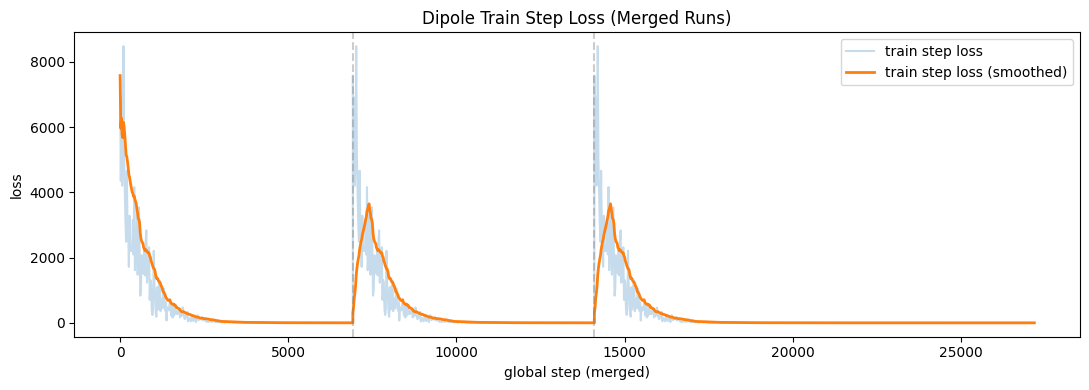

In [4]:
import matplotlib.pyplot as plt

train_step = df[df.get('split') == 'train'].copy() if 'split' in df.columns else pd.DataFrame()
if not train_step.empty and 'loss' in train_step.columns:
    train_step['loss_smooth'] = train_step['loss'].rolling(25, min_periods=1).mean()

plt.figure(figsize=(11, 4))
if not train_step.empty and 'loss' in train_step.columns:
    plt.plot(train_step['step_global'], train_step['loss'], alpha=0.25, label='train step loss')
    plt.plot(train_step['step_global'], train_step['loss_smooth'], linewidth=2, label='train step loss (smoothed)')

if not summary_df.empty:
    boundaries = summary_df['global_step_min'].tolist()[1:]
    for b in boundaries:
        plt.axvline(b, color='gray', linestyle='--', alpha=0.4)

plt.xlabel('global step (merged)')
plt.ylabel('loss')
plt.title('Dipole Train Step Loss (Merged Runs)')
plt.legend()
plt.tight_layout()
plt.show()


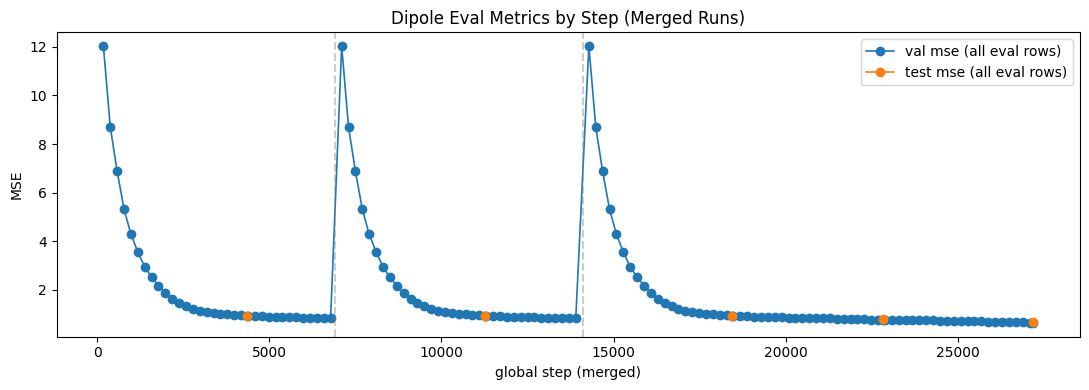

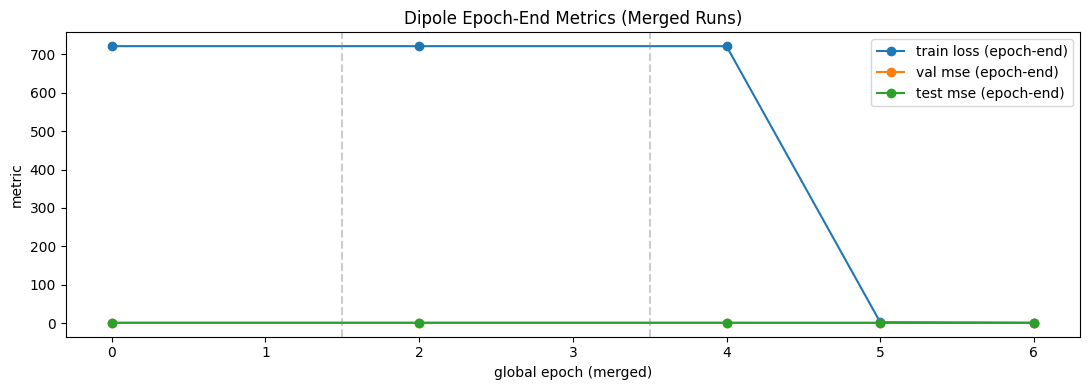

In [5]:
# Eval/train metrics with mixed logging styles
# Some runs log eval every step (eval_scope='step'), others only at epoch-end.

eval_rows = pd.DataFrame()
if 'val_mse' in df.columns:
    eval_rows = df[df['val_mse'].notna()].copy()
    if 'eval_scope' not in eval_rows.columns:
        eval_rows['eval_scope'] = 'unknown'
    eval_rows['eval_scope'] = eval_rows['eval_scope'].fillna('unknown')

train_epoch_rows = pd.DataFrame()
if 'train_loss_epoch' in df.columns:
    train_epoch_rows = df[df['train_loss_epoch'].notna()].copy()
    if 'eval_scope' not in train_epoch_rows.columns:
        train_epoch_rows['eval_scope'] = 'unknown'
    train_epoch_rows['eval_scope'] = train_epoch_rows['eval_scope'].fillna('unknown')

# 1) Step-domain view (most faithful when eval_scope='step' exists)
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 4))
if not eval_rows.empty:
    plt.plot(eval_rows['step_global'], eval_rows['val_mse'], marker='o', linewidth=1.2, label='val mse (all eval rows)')
    if 'test_mse' in eval_rows.columns and eval_rows['test_mse'].notna().any():
        plt.plot(eval_rows['step_global'], eval_rows['test_mse'], marker='o', linewidth=1.2, label='test mse (all eval rows)')

if not summary_df.empty:
    boundaries = summary_df['global_step_min'].tolist()[1:]
    for b in boundaries:
        plt.axvline(b, color='gray', linestyle='--', alpha=0.4)

plt.xlabel('global step (merged)')
plt.ylabel('MSE')
plt.title('Dipole Eval Metrics by Step (Merged Runs)')
plt.legend()
plt.tight_layout()
plt.show()

# 2) Epoch-end-only view (avoids mixing frequent step-evals into epoch summary)
epoch_eval = pd.DataFrame()
if not eval_rows.empty:
    epoch_eval = eval_rows[eval_rows['eval_scope'].astype(str) == 'epoch'].copy()

epoch_train = pd.DataFrame()
if not train_epoch_rows.empty:
    epoch_train = train_epoch_rows[(train_epoch_rows.get('split') == 'train_epoch') | (train_epoch_rows['eval_scope'].astype(str) == 'epoch')].copy()
    epoch_train = epoch_train.sort_values(['epoch_global', 'step_global']).groupby('epoch_global', as_index=False).last()

if not epoch_eval.empty:
    epoch_eval = epoch_eval.sort_values(['epoch_global', 'step_global']).groupby('epoch_global', as_index=False).last()

plt.figure(figsize=(11, 4))
if not epoch_train.empty:
    plt.plot(epoch_train['epoch_global'], epoch_train['train_loss_epoch'], marker='o', label='train loss (epoch-end)')
if not epoch_eval.empty:
    plt.plot(epoch_eval['epoch_global'], epoch_eval['val_mse'], marker='o', label='val mse (epoch-end)')
    if 'test_mse' in epoch_eval.columns and epoch_eval['test_mse'].notna().any():
        plt.plot(epoch_eval['epoch_global'], epoch_eval['test_mse'], marker='o', label='test mse (epoch-end)')

if not summary_df.empty:
    epoch_boundaries = summary_df['global_epoch_min'].tolist()[1:]
    for b in epoch_boundaries:
        plt.axvline(b - 0.5, color='gray', linestyle='--', alpha=0.4)

plt.xlabel('global epoch (merged)')
plt.ylabel('metric')
plt.title('Dipole Epoch-End Metrics (Merged Runs)')
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
# View the merged dataframe (with epoch_global/step_global)
df.head(20)


,epoch,step,split,loss,train_mse,lr,eval_scope,eval_batches,eval_max_batches,train_loss_epoch,...,test_mse,test_mse_lo,test_mse_hi,test_mae,test_mae_lo,test_mae_hi,epoch_global,step_global,run_idx,run_name
0,0,20,train,7575.683922,7575.552423,0.000011,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,dipole-prod-standard-ckpt-a100x8-20260219-034602
1,0,40,train,4349.044196,4348.912855,0.000020,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,20,0,dipole-prod-standard-ckpt-a100x8-20260219-034602
2,0,60,train,6905.257080,6905.125686,0.000020,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,40,0,dipole-prod-standard-ckpt-a100x8-20260219-034602
3,0,80,train,4203.163492,4203.032066,0.000020,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,60,0,dipole-prod-standard-ckpt-a100x8-20260219-034602
4,0,100,train,5348.876083,5348.744641,0.000020,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,80,0,dipole-prod-standard-ckpt-a100x8-20260219-034602
5,0,120,train,8478.028662,8477.897389,0.000020,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,100,0,dipole-prod-standard-ckpt-a100x8-20260219-034602
6,0,140,train,5013.238627,5013.107142,0.000020,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,120,0,dipole-prod-standard-ckpt-a100x8-20260219-034602
7,0,160,train,3978.003978,3977.872552,0.000020,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,140,0,dipole-prod-standard-ckpt-a100x8-20260219-034602
8,0,180,train,3038.130807,3037.999560,0.000020,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,160,0,dipole-prod-standard-ckpt-a100x8-20260219-034602
9,0,200,train,2484.320573,2484.189314,0.000020,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,0,180,0,dipole-prod-standard-ckpt-a100x8-20260219-034602


## Literature-aligned replot strategy

Given mixed logging cadence across your two artifact folders (one mostly epoch-end, one frequent step-evals), a cleaner statistical view is:

- Use **global step** as the primary axis for comparability.
- Use **robust summaries** (median + IQR ribbon) in fixed step bins, rather than only raw lines.
- Keep a separate **epoch-end-only** view (last eval per epoch) for checkpoint-style comparisons.

Why this is standard/defensible:
- **Agarwal et al. (NeurIPS 2021)** recommend robust aggregates and interval estimates when runs are noisy/sparse: https://arxiv.org/abs/2108.13264
- **Henderson et al. (AAAI 2018)** emphasize variance-aware reporting and avoiding over-interpretation of noisy curves: https://arxiv.org/abs/1709.06560
- **Cleveland LOWESS/robust smoothing** motivates robust local trend estimation in noisy scatter/time-series style data: https://stat.ethz.ch/R-manual/R-devel/RHOME/library/stats/html/lowess.html


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tunable width for robust binning in global-step space.
STEP_BIN = 250


def binned_robust_summary(frame: pd.DataFrame, x_col: str, y_col: str, step_bin: int = STEP_BIN) -> pd.DataFrame:
    cols = [x_col, y_col]
    w = frame[cols].dropna().copy()
    if w.empty:
        return pd.DataFrame(columns=['x', 'y_med', 'y_q25', 'y_q75', 'n'])

    w = w.sort_values(x_col).reset_index(drop=True)
    x_min = float(w[x_col].min())
    x_max = float(w[x_col].max())

    if x_max == x_min:
        return pd.DataFrame({
            'x': [x_min],
            'y_med': [float(w[y_col].median())],
            'y_q25': [float(w[y_col].quantile(0.25))],
            'y_q75': [float(w[y_col].quantile(0.75))],
            'n': [int(len(w))],
        })

    edges = np.arange(x_min, x_max + step_bin, step_bin)
    if len(edges) < 2:
        edges = np.array([x_min, x_min + step_bin])

    w['_bin'] = np.digitize(w[x_col].to_numpy(), edges, right=False) - 1

    out = (
        w.groupby('_bin', as_index=False)
         .agg(
             x=(x_col, 'median'),
             y_med=(y_col, 'median'),
             y_q25=(y_col, lambda s: s.quantile(0.25)),
             y_q75=(y_col, lambda s: s.quantile(0.75)),
             n=(y_col, 'size'),
         )
         .sort_values('x')
         .reset_index(drop=True)
    )

    # Drop tiny bins to reduce instability.
    out = out[out['n'] >= 2].reset_index(drop=True)
    return out


# Source subsets
train_rows = df[df.get('split') == 'train'].copy() if 'split' in df.columns else pd.DataFrame()
eval_rows = df[df['val_mse'].notna()].copy() if 'val_mse' in df.columns else pd.DataFrame()
if not eval_rows.empty:
    if 'eval_scope' not in eval_rows.columns:
        eval_rows['eval_scope'] = 'unknown'
    eval_rows['eval_scope'] = eval_rows['eval_scope'].fillna('unknown')

# Robust summaries
train_robust = binned_robust_summary(train_rows, 'step_global', 'loss', STEP_BIN) if not train_rows.empty else pd.DataFrame()
val_robust = binned_robust_summary(eval_rows, 'step_global', 'val_mse', STEP_BIN) if not eval_rows.empty else pd.DataFrame()
test_robust = binned_robust_summary(eval_rows, 'step_global', 'test_mse', STEP_BIN) if (not eval_rows.empty and 'test_mse' in eval_rows.columns and eval_rows['test_mse'].notna().any()) else pd.DataFrame()

print('train robust bins:', len(train_robust), 'val robust bins:', len(val_robust), 'test robust bins:', len(test_robust))


train robust bins: 109 val robust bins: 29 test robust bins: 0


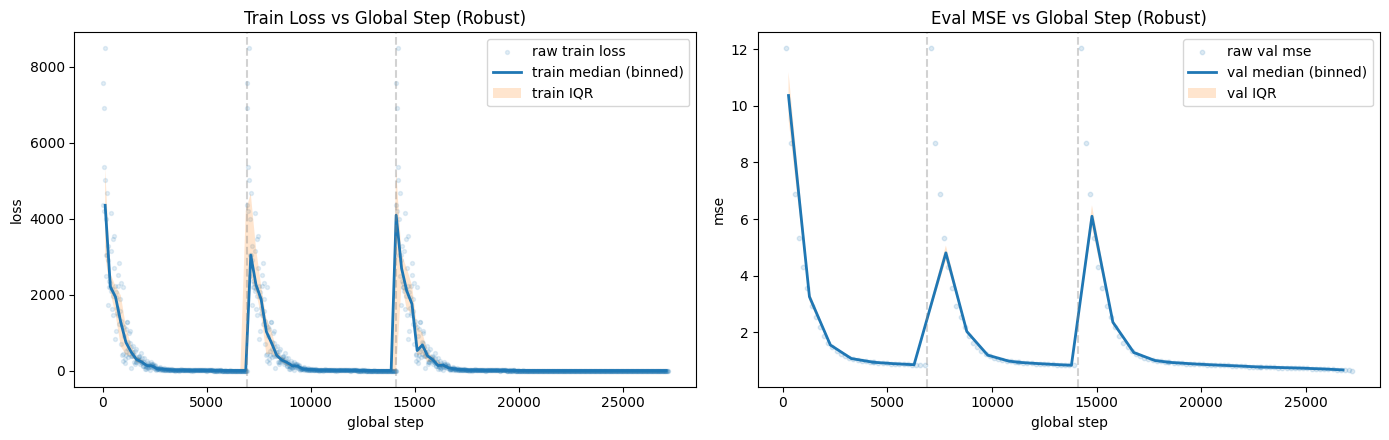

In [8]:
# Robust step-domain plots: median + IQR (literature-aligned for noisy curves)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Train loss
ax = axes[0]
if not train_rows.empty:
    ax.scatter(train_rows['step_global'], train_rows['loss'], s=8, alpha=0.12, label='raw train loss')
if not train_robust.empty:
    ax.plot(train_robust['x'], train_robust['y_med'], linewidth=2, label='train median (binned)')
    ax.fill_between(train_robust['x'], train_robust['y_q25'], train_robust['y_q75'], alpha=0.2, label='train IQR')
for b in summary_df['global_step_min'].tolist()[1:]:
    ax.axvline(b, color='gray', linestyle='--', alpha=0.35)
ax.set_title('Train Loss vs Global Step (Robust)')
ax.set_xlabel('global step')
ax.set_ylabel('loss')
ax.legend(loc='best')

# Eval MSE
ax = axes[1]
if not eval_rows.empty:
    ax.scatter(eval_rows['step_global'], eval_rows['val_mse'], s=10, alpha=0.15, label='raw val mse')
if not val_robust.empty:
    ax.plot(val_robust['x'], val_robust['y_med'], linewidth=2, label='val median (binned)')
    ax.fill_between(val_robust['x'], val_robust['y_q25'], val_robust['y_q75'], alpha=0.2, label='val IQR')
if not test_robust.empty:
    ax.plot(test_robust['x'], test_robust['y_med'], linewidth=2, label='test median (binned)')
    ax.fill_between(test_robust['x'], test_robust['y_q25'], test_robust['y_q75'], alpha=0.15, label='test IQR')
for b in summary_df['global_step_min'].tolist()[1:]:
    ax.axvline(b, color='gray', linestyle='--', alpha=0.35)
ax.set_title('Eval MSE vs Global Step (Robust)')
ax.set_xlabel('global step')
ax.set_ylabel('mse')
ax.legend(loc='best')

plt.tight_layout()
plt.show()


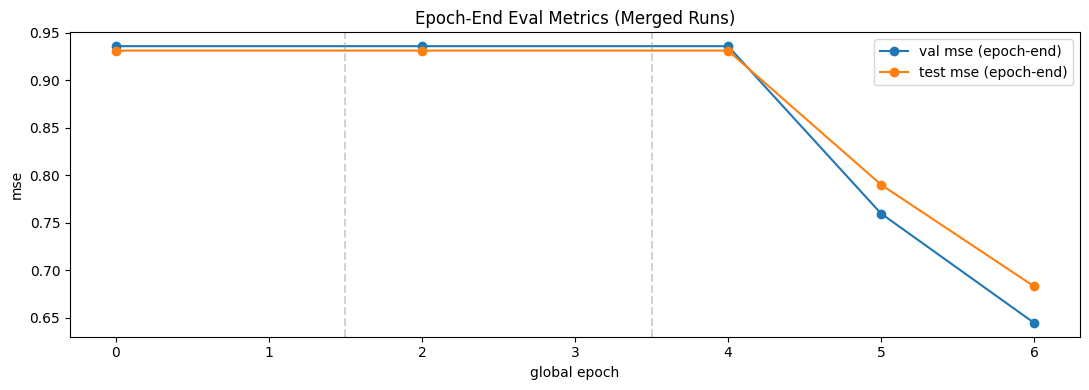

,metric,points,best,final_median,auc_mean
0,val_mse (all eval rows),139,0.644419,0.682966,1.863062
1,test_mse (all eval rows),5,0.682912,0.931308,0.880467
2,val_mse (epoch-end),5,0.644419,0.759654,0.882310
3,test_mse (epoch-end),5,0.682912,0.790062,0.887067


In [9]:
# Epoch-end-only view + scalar summary stats (best/final-window/AUC)

def scalar_curve_stats(frame: pd.DataFrame, x_col: str, y_col: str, final_k: int = 10) -> dict:
    t = frame[[x_col, y_col]].dropna().sort_values(x_col)
    if t.empty:
        return {'points': 0, 'best': np.nan, 'final_median': np.nan, 'auc_mean': np.nan}
    y = t[y_col].to_numpy(dtype=float)
    x = t[x_col].to_numpy(dtype=float)
    best = float(np.min(y))
    final_median = float(np.median(y[-min(final_k, len(y)):]))
    if len(t) >= 2 and (x[-1] - x[0]) > 0:
        trap_fn = getattr(np, 'trapezoid', None)
        if trap_fn is None:
            trap_fn = np.trapz
        auc_mean = float(trap_fn(y, x) / (x[-1] - x[0]))
    else:
        auc_mean = float(np.mean(y))
    return {'points': int(len(t)), 'best': best, 'final_median': final_median, 'auc_mean': auc_mean}

# Epoch-end eval rows (if available)
epoch_end_eval = pd.DataFrame()
if not eval_rows.empty:
    epoch_end_eval = eval_rows[eval_rows['eval_scope'].astype(str) == 'epoch'].copy()
    epoch_end_eval = epoch_end_eval.sort_values(['epoch_global', 'step_global']).groupby('epoch_global', as_index=False).last()

# Fallback epoch view: last eval inside each epoch when explicit epoch eval is sparse
if epoch_end_eval.empty and not eval_rows.empty:
    epoch_end_eval = eval_rows.sort_values(['epoch_global', 'step_global']).groupby('epoch_global', as_index=False).last()

plt.figure(figsize=(11, 4))
if not epoch_end_eval.empty:
    plt.plot(epoch_end_eval['epoch_global'], epoch_end_eval['val_mse'], marker='o', label='val mse (epoch-end)')
    if 'test_mse' in epoch_end_eval.columns and epoch_end_eval['test_mse'].notna().any():
        plt.plot(epoch_end_eval['epoch_global'], epoch_end_eval['test_mse'], marker='o', label='test mse (epoch-end)')
for b in summary_df['global_epoch_min'].tolist()[1:]:
    plt.axvline(b - 0.5, color='gray', linestyle='--', alpha=0.35)
plt.title('Epoch-End Eval Metrics (Merged Runs)')
plt.xlabel('global epoch')
plt.ylabel('mse')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

stats_rows = []
if not eval_rows.empty:
    stats_rows.append({'metric': 'val_mse (all eval rows)', **scalar_curve_stats(eval_rows, 'step_global', 'val_mse')})
    if 'test_mse' in eval_rows.columns and eval_rows['test_mse'].notna().any():
        stats_rows.append({'metric': 'test_mse (all eval rows)', **scalar_curve_stats(eval_rows, 'step_global', 'test_mse')})
if not epoch_end_eval.empty:
    stats_rows.append({'metric': 'val_mse (epoch-end)', **scalar_curve_stats(epoch_end_eval, 'epoch_global', 'val_mse', final_k=3)})
    if 'test_mse' in epoch_end_eval.columns and epoch_end_eval['test_mse'].notna().any():
        stats_rows.append({'metric': 'test_mse (epoch-end)', **scalar_curve_stats(epoch_end_eval, 'epoch_global', 'test_mse', final_k=3)})

stats_df = pd.DataFrame(stats_rows)
stats_df
